## Mice Maze Analysis

The following notebook is adapted from:

Rosenberg, M., Zhang, T., Perona, P., and Meister, M. (2021). Mice in a labyrinth exhibit rapid learning, sudden insight, and efficient exploration. ELife 10, e66175. (https://doi.org/10.7554/eLife.66175)

https://github.com/markusmeister/Rosenberg-2021-Repository

To run the code with their data, please download their github repo, and place this notebook in the main folder, along with flow_tree_utils.py.

# Imports

In [1]:
# Imports
import pickle
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import patches
from copy import deepcopy
import plotly.graph_objects as go
from scipy.optimize import curve_fit
from dataclasses import make_dataclass

import sys

module_path = "code"
if module_path not in sys.path:
    sys.path.append(module_path)

# Markus's code
from MM_Plot_Utils import plot, hist
from MM_Maze_Utils import *
from MM_Traj_Utils import *

from flow_tree_utils import generate_flow_tree_from_trajs, plot_flow_tree

%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
TestTrajModule()

'OK'

In [3]:
# Some lists of nicknames for mice
UnrewNames = ["B5", "B6", "B7", "D3", "D4", "D5", "D6", "D7", "D8", "D9"]
RewNames = ["B1", "B2", "B3", "B4", "C1", "C3", "C6", "C7", "C8", "C9"]
AllNames = RewNames + UnrewNames
UnrewNamesSub = [
    "B5",
    "B6",
    "B7",
    "D3",
    "D4",
    "D5",
    "D7",
    "D8",
    "D9",
]  # excluding D6 which barely entered the maze

In [4]:
# Define maze
ma = NewMaze(6)

In [5]:
# Define the 3 modes of behavior
leave = 0
drink = 1
explore = 2

# Modes of behavior
Divide each bout of the trajectory into
- Leave: direct path to the exit at the end of the bout
- Drink: all direct paths to water
- Explore: everything else

A direct path to a target is the longest sequence of nodes without reversals that ends at the target.

Goals: 
- determine fraction of time/nodes in each mode
- determine transition rates (per time/node) between modes
- restrict analysis to one mode, e.g. concatenate all the paths in exploration mode and analyze their efficiency

Method:
- Call each piece of a bout that corresponds to one mode a 'clip' (as in cutting a video recording into clips)
- For each bout identify all the clips and make an array of [mode, start node index, number of nodes]. Combine those arrays into a list. 

Algorithm:
- Each clip should include start and end node. The end node of one is the start node of the next.
- Start with the exit. FInd the direct path. That defines the 'leave mode' clip for this bout. Find the start node of that clip.
- If the start node is the water port, find the direct path that leads there: 'drink' clip
- If it's some other node, trace back to either the exit or the water port: 'explore' clip
- If it's the exit, move on to the next bout.
- Sort all the clips in chronological order.

The routine `SplitModeClips(tf,ma,re=True)` takes care of all that.

## Mode analysis for all animals
For each animal we want:
- Number of nodes and frames in each mode
- Transition probabilities between modes
- Efficiency analysis (New nodes vs all nodes) for exploration mode specifically

In [6]:
# Define the 3 states
leave = 0
drink = 1
explore = 2  # the 3 modes

In [7]:
# Mode analysis for all animals
Names = RewNames + UnrewNamesSub
k = len(RewNames)
for i, nickname in enumerate(Names):
    tf = LoadTraj(nickname + "-tf")
    cl = SplitModeClips(
        tf, ma, re=i < k
    )  # find the clips; no drink mode for unrewarded animals
    ti = np.array(
        [tf.no[c[0]][c[1] + c[2], 1] - tf.no[c[0]][c[1], 1] for c in cl]
    )  # duration in frames of each clip
    nn = np.array(
        [
            np.sum(cl[np.where(cl[:, 3] == leave)][:, 2]),
            np.sum(cl[np.where(cl[:, 3] == drink)][:, 2]),
            np.sum(cl[np.where(cl[:, 3] == explore)][:, 2]),
        ]
    )  # number of node steps in each mode
    nf = np.array(
        [
            np.sum(ti[np.where(cl[:, 3] == leave)]),
            np.sum(ti[np.where(cl[:, 3] == drink)]),
            np.sum(ti[np.where(cl[:, 3] == explore)]),
        ]
    )  # number of frames in each mode
    tr = np.zeros((3, 3))  # number of transitions between the 3 modes
    for i in range(1, len(cl)):
        tr[cl[i - 1, 3], cl[i, 3]] += 1
    ce = cl[np.where(cl[:, 3] == explore)]  # clips of exploration
    ne = np.concatenate(
        [tf.no[c[0]][c[1] : c[1] + c[2], 0] for c in ce]
    )  # nodes excluding the last state in each clip
    le = 6  # end nodes only
    ln = list(range(2**le - 1, 2 ** (le + 1) - 1))  # list of node numbers in level le
    ns = ne[np.isin(ne, ln)]  # restricted to desired nodes
    wcn = NewNodes4(
        ns, nf[2] / len(ns)
    )  # compute new nodes vs all nodes for exploration mode only
    with open(
        "outdata/" + nickname + "-Modes1", "wb"
    ) as f:  # save in one file per animal
        pickle.dump((nn, nf, tr, wcn), f)


## Occupancy and transitions between modes

In [8]:
# Combine all the mode statistics from all animals into arrays
Names = RewNames + UnrewNamesSub
k = len(RewNames)
a = len(Names)
nn = np.zeros((a, 3))  # number of nodes in each mode
nf = np.zeros((a, 3))  # number of frames in each mode
tr = np.zeros((a, 3, 3))  # number of transitions between modes
ff = np.zeros((a, 3))  # fraction of frames in each mode
wcn = []  # these arrays have different shape
for i, nickname in enumerate(Names):
    with open("outdata/" + nickname + "-Modes1", "rb") as f:
        nn1, nf1, tr1, wcn1 = pickle.load(f)
    nn[i] = nn1
    nf[i] = nf1
    tr[i] = tr1
    wcn += [wcn1]
    s = sum(nf[i])
    ff[i] = nf[i] / s


### Figure 6A, Figure 6–figure supplement 1A

In [9]:
# List fraction of time in each mode
print("Fraction of frames in each mode")
print("     home | drink | explore")
print("rewarded:")
for i in range(k):
    print(Names[i] + ": {:4.3f} | {:4.3f} | {:4.3f}".format(*ff[i]))
print("------------------------")
print("Av: {:4.3f} | {:4.3f} | {:4.3f}".format(*np.mean(ff[:k], axis=0)))
print("SD: {:4.3f} | {:4.3f} | {:4.3f}".format(*np.std(ff[:k], axis=0)))
print("\nunrewarded:")
for i in range(k, len(Names)):
    print(Names[i] + ": {:4.3f} | {:4.3f} | {:4.3f}".format(*ff[i]))
print("------------------------")
print("Av: {:4.3f} | {:4.3f} | {:4.3f}".format(*np.mean(ff[k:], axis=0)))
print("SD: {:4.3f} | {:4.3f} | {:4.3f}".format(*np.std(ff[k:], axis=0)))

Fraction of frames in each mode
     home | drink | explore
rewarded:
B1: 0.052 | 0.113 | 0.835
B2: 0.057 | 0.154 | 0.789
B3: 0.052 | 0.071 | 0.877
B4: 0.057 | 0.076 | 0.867
C1: 0.050 | 0.098 | 0.852
C3: 0.086 | 0.100 | 0.814
C6: 0.063 | 0.139 | 0.798
C7: 0.040 | 0.083 | 0.877
C8: 0.038 | 0.085 | 0.877
C9: 0.031 | 0.113 | 0.857
------------------------
Av: 0.053 | 0.103 | 0.844
SD: 0.014 | 0.026 | 0.032

unrewarded:
B5: 0.065 | 0.000 | 0.935
B6: 0.057 | 0.000 | 0.943
B7: 0.068 | 0.000 | 0.932
D3: 0.063 | 0.000 | 0.937
D4: 0.063 | 0.000 | 0.937
D5: 0.052 | 0.000 | 0.948
D7: 0.026 | 0.000 | 0.974
D8: 0.038 | 0.000 | 0.962
D9: 0.042 | 0.000 | 0.958
------------------------
Av: 0.053 | 0.000 | 0.947
SD: 0.014 | 0.000 | 0.014


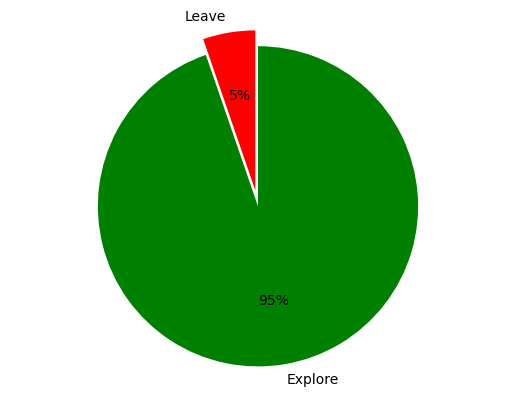

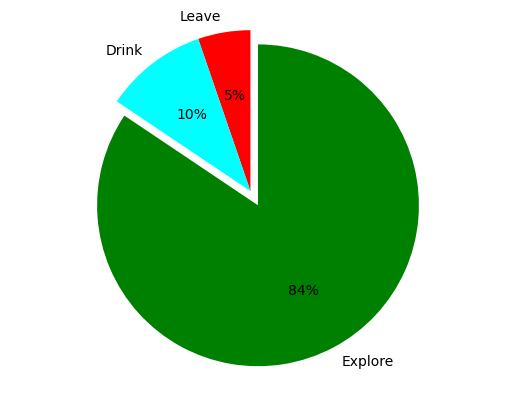

In [10]:
# Pie charts, where the slices will be ordered and plotted counter-clockwise:
labels = "Leave", "Explore"
av = np.mean(ff[k:], axis=0)
sizes = [av[0], av[2]]
explode = (0, 0.1)  # only "explode" the 2nd slice
fig1, ax1 = plt.subplots()
ax1.pie(
    sizes,
    explode=explode,
    labels=labels,
    autopct="%1.0f%%",
    shadow=False,
    startangle=90,
    colors=["red", "green"],
)
# ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.0f%%',
#         shadow=True, startangle=90)
ax1.axis("equal")  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.savefig("figs/UnrewPie.pdf")
plt.show()

labels = "Leave", "Drink", "Explore"
av = np.mean(ff[:k], axis=0)
sizes = [av[0], av[1], av[2]]
explode = (0, 0, 0.1)  # only "explode" the 2nd slice
fig1, ax1 = plt.subplots()
ax1.pie(
    sizes,
    explode=explode,
    labels=labels,
    autopct="%1.0f%%",
    shadow=False,
    startangle=90,
    colors=["red", "cyan", "green"],
)
# ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.0f%%',
#         shadow=True, startangle=90)
ax1.axis("equal")  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.savefig("figs/RewPie.pdf")
plt.show()

In [11]:
# transitions between modes
print("Prob of transition between leave, drink, explore:")
print("     l->d  | l->e  | d->l  | d->e  | e->h  | e->d")
n = []
for i, nickname in enumerate(RewNames):
    s = tr[i, 0, 1] + tr[i, 0, 2]  # ignore the h->h transition
    nn = tr[i, 0, 1:] / s
    s = tr[i, 1, 0] + tr[i, 1, 2]
    nn = np.append(nn, [tr[i, 1, 0] / s, tr[i, 1, 2] / s])
    s = tr[i, 2, 0] + tr[i, 2, 1]
    nn = np.append(nn, [tr[i, 2, 0] / s, tr[i, 2, 1] / s])
    n += [nn]
    print(nickname, ": {:4.3f} | {:4.3f}".format(nn[0], nn[1]), end="")
    print(" | {:4.3f} | {:4.3f}".format(nn[2], nn[3]), end="")
    print(" | {:4.3f} | {:4.3f}".format(nn[4], nn[5]))
n = np.array(n)
av = np.mean(n, axis=0)
sd = np.std(n, axis=0)
print("----------------------------------------------")
print("Av : {:4.3f} | {:4.3f} | {:4.3f} | {:4.3f} | {:4.3f} | {:4.3f}".format(*av))
print("SD : {:4.3f} | {:4.3f} | {:4.3f} | {:4.3f} | {:4.3f} | {:4.3f}".format(*sd))


Prob of transition between leave, drink, explore:
     l->d  | l->e  | d->l  | d->e  | e->h  | e->d
B1 : 0.561 | 0.439 | 0.119 | 0.881 | 0.319 | 0.681
B2 : 0.571 | 0.429 | 0.075 | 0.925 | 0.377 | 0.623
B3 : 0.172 | 0.828 | 0.025 | 0.975 | 0.605 | 0.395
B4 : 0.553 | 0.447 | 0.127 | 0.873 | 0.437 | 0.563
C1 : 0.663 | 0.337 | 0.199 | 0.801 | 0.366 | 0.634
C3 : 0.610 | 0.390 | 0.156 | 0.844 | 0.552 | 0.448
C6 : 0.507 | 0.493 | 0.107 | 0.893 | 0.354 | 0.646
C7 : 0.325 | 0.675 | 0.058 | 0.942 | 0.324 | 0.676
C8 : 0.584 | 0.416 | 0.086 | 0.914 | 0.426 | 0.574
C9 : 0.557 | 0.443 | 0.060 | 0.940 | 0.230 | 0.770
----------------------------------------------
Av : 0.510 | 0.490 | 0.101 | 0.899 | 0.399 | 0.601
SD : 0.141 | 0.141 | 0.049 | 0.049 | 0.106 | 0.106


### Figure 6–figure supplement 1B

In [12]:
# markdown table of transition probabilities
print("|from / to:   | leave | drink | explore |")
print("|:--|:-:|:-:|:-:|")
print(
    "|**leave**|   |{:3.2f} ± {:3.2f}|{:3.2f} ± {:3.2f}|".format(
        av[0], sd[0], av[1], sd[1]
    )
)
print(
    "|**drink**|{:3.2f} ± {:3.2f}|  |{:3.2f} ± {:3.2f}|".format(
        av[2], sd[2], av[3], sd[3]
    )
)
print(
    "|**explore**|{:3.2f} ± {:3.2f}|{:3.2f} ± {:3.2f}|   |".format(
        av[4], sd[4], av[5], sd[5]
    )
)


|from / to:   | leave | drink | explore |
|:--|:-:|:-:|:-:|
|**leave**|   |0.51 ± 0.14|0.49 ± 0.14|
|**drink**|0.10 ± 0.05|  |0.90 ± 0.05|
|**explore**|0.40 ± 0.11|0.60 ± 0.11|   |


### Mode fraction vs time

In [90]:
# Histogram time in each mode for rewarded animals
# Each clip records the bout number, start state in the bout, number of steps, and mode
Names = RewNames
te = 25000  # max time
nb = 50  # number of bins
tl = np.linspace(0, te, nb, endpoint=False)  # left end of each bin
tb = te / nb  # bin width
ti = np.zeros((len(Names), nb, 3))
mode_traj_dict = {0: [], 1: [], 2: []}
print(Names)
for i, nickname in enumerate(Names):
    tf = LoadTraj(nickname + "-tf")
    cl = SplitModeClips(tf, ma, re=True)  # find the clips
    for c in cl:
        b = c[0]  # bout
        n0 = tf.no[b][c[1]]  # start node
        b0 = (tf.fr[b, 0] + n0[1]) / 30  # time of clip start in s
        n1 = tf.no[b][c[1] + c[2]]  # end node
        b1 = (tf.fr[b, 0] + n1[1]) / 30  # time of clip end in s
        m = c[3]  # mode

        # ── collect trajectory (independent of time binning) ──
        if c[2] >= 5:
            traj = tf.no[b][c[1] : c[1] + c[2] + 1, 0]  # +1 to include the end node
            mode_traj_dict[m].append(traj)

        if b0 < te:  # if left end is before the max time
            j0 = int(b0 // tb)  # bin containing left end
            if b1 > te:  # if right end is after the max time
                b1 = te - 1e-8  # set it to the max time minus a little for comfort
            j1 = int(b1 // tb)  # bin containing right end
            if j1 > j0:  # if clip ends in a different bin
                ti[i, j0, m] += (j0 + 1) * tb - b0  # part of the first bin
                ti[i, j0 + 1 : j1, m] += tb  # all of the intervening bins
                ti[i, j1, m] += b1 - j1 * tb  # part of the last bin
            else:  # if clip starts and ends in same bin
                ti[i, j0, m] += b1 - b0

print(ti.shape)
ti /= tb  # normalize to bin width to get fraction of time in each bin
ts = np.sum(ti, axis=-1)  # sum the 3 time fractions in each bin
tf = ti / (
    ts.reshape(ts.shape + (1,)) + 1e-8
)  # fraction in each mode in each bin (avoid divide by zero)

['B1', 'B2', 'B3', 'B4', 'C1', 'C3', 'C6', 'C7', 'C8', 'C9']
(10, 50, 3)


In [14]:
for m in mode_traj_dict:
    traj_counts = {}

    for traj in mode_traj_dict[m]:
        traj_counts[traj[0]] = traj_counts.get(traj[0], 0) + 1

    print(sorted(traj_counts.keys(), key=lambda x: traj_counts[x]))
    print(traj_counts)

[69, 38, 68, 111, 44, 118, 31, 50, 90, 108, 54, 43, 33, 70, 75, 49, 46, 67, 80, 89, 48, 99, 55, 92, 109, 112, 93, 39, 45, 36, 71, 81, 77, 82, 35, 73, 107, 101, 94, 37, 120, 121, 85, 88, 110, 119, 40, 114, 86, 124, 96, 91, 79, 47, 34, 58, 100, 60, 122, 63, 97, 95, 98, 53, 64, 61, 117, 52, 74, 41, 65, 62, 59, 32, 42, 84, 83, 51, 66, 125, 126, 103, 104, 123, 105, 106, 57, 115, 116]
{106: 35, 101: 5, 39: 4, 43: 2, 33: 2, 59: 12, 83: 19, 63: 8, 104: 28, 57: 38, 51: 23, 45: 4, 34: 7, 70: 2, 84: 18, 105: 32, 32: 14, 58: 7, 42: 16, 94: 5, 126: 27, 97: 8, 100: 7, 115: 300, 116: 302, 61: 10, 36: 4, 66: 26, 103: 27, 125: 26, 37: 5, 71: 4, 81: 4, 123: 30, 117: 10, 75: 2, 98: 9, 41: 11, 53: 9, 77: 4, 40: 6, 64: 9, 48: 3, 120: 5, 99: 3, 52: 10, 60: 7, 122: 7, 55: 3, 69: 1, 114: 6, 38: 1, 65: 11, 68: 1, 74: 10, 86: 6, 62: 11, 124: 6, 96: 6, 82: 4, 35: 4, 121: 5, 49: 2, 91: 6, 46: 2, 85: 5, 111: 1, 92: 3, 44: 1, 109: 3, 88: 5, 79: 6, 118: 1, 67: 2, 112: 3, 73: 4, 93: 3, 80: 2, 31: 1, 95: 8, 47: 6, 89:

In [172]:
import networkx as nx


def get_heaviest_path(tree, root):
    # Get all leaves (nodes with degree 1, excluding the root)
    leaves = [node for node in tree.nodes() if tree.degree(node) == 1 and node != root]
    # leaves = [node for node in tree.nodes() if tree.nodes[node].get("color", "white") in ["yellow", "green"]]

    def dfs(node, current_path, current_weight):
        nonlocal max_weight, heaviest_path

        # If we're at a leaf (degree 1 and not root)
        if node in leaves:
            if current_weight > max_weight:
                max_weight = current_weight
                heaviest_path = current_path.copy()
            return

        # Explore all children
        for neighbor in tree.neighbors(node):
            if neighbor not in current_path:  # Avoid cycles
                edge_weight = tree[node][neighbor]["weight"]
                current_path.append(neighbor)
                dfs(neighbor, current_path, current_weight + edge_weight)
                current_path.pop()

    max_weight = float("-inf")
    heaviest_path = None
    dfs(root, [root], 0)

    return (
        heaviest_path,
        max_weight,
        [
            tree[heaviest_path[i]][heaviest_path[i + 1]]["weight"]
            for i in range(len(heaviest_path) - 1)
        ],
    )


def extract_tree_features(graph, root):
    # Number of Nodes
    num_nodes = graph.number_of_nodes()

    # Tree Depth (Height)
    def tree_depth(graph, root):
        depths = nx.single_source_shortest_path_length(graph, root)
        return max(depths.values())

    depth = tree_depth(graph, root)

    # Diameter
    diameter = nx.diameter(graph)

    backbone_path, max_weight, weights = get_heaviest_path(graph, root)
    backbone_thickness = np.mean(weights) / max_weight

    # Number of Leaves
    num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)

    # Branching Factor
    branching_factors = [len(list(graph.neighbors(node))) for node in graph.nodes()]
    avg_branching_factor = np.mean(branching_factors)

    # Put all features in a list
    features = [
        num_nodes,
        num_leaves,
        depth,
        avg_branching_factor,
        backbone_thickness,
        diameter,
    ]

    return features


def compare_flow_tree_groups(
    results_df,
    group1_trees,
    group2_trees,
    normalise=False,
    include_embeddings=True,
    hypothesis_test_types=["permutation"],
    group1_name="Group 1",
    group2_name="Group 2",
    hypothesis="",
):
    """Compare two groups of flow trees on various structural metrics.

    Args:
        results_df
        group1_trees: List of networkx graphs for first group
        group2_trees: List of networkx graphs for second group
        group1_name: Name of first group for results
        group2_name: Name of second group for results
        hypothesis: Hypothesis being tested

    Returns:
        DataFrame containing test results
    """
    feature_names = [
        "num_nodes",
        "num_leaves",
        "depth",
        "avg_branching_factor",
        "backbone_thickness",
        "diameter",
    ]

    # Add embeddings to features arrays
    group1_features = np.array([extract_tree_features(G, 0) for G in group1_trees])
    group2_features = np.array([extract_tree_features(G, 0) for G in group2_trees])

    # Test each feature
    for i, feature_name in enumerate(feature_names):
        group1_feature = group1_features[:, i]
        group2_feature = group2_features[:, i]

        if normalise:
            # Normalize features to 0-1 range
            all_features = np.concatenate([group1_feature, group2_feature])
            feature_min = np.min(all_features)
            feature_max = np.max(all_features)

            # Avoid division by zero if min==max
            if feature_max > feature_min:
                group1_feature = (group1_feature - feature_min) / (
                    feature_max - feature_min
                )
                group2_feature = (group2_feature - feature_min) / (
                    feature_max - feature_min
                )

        if "t-test" in hypothesis_test_types:
            # T-test
            t_stat, p_val = stats.ttest_ind(group1_feature, group2_feature)
            results_df.loc[len(results_df)] = {
                "hypothesis": hypothesis,
                "test_type": "t-test",
                "group1_name": group1_name,
                "group2_name": group2_name,
                "group1_mean": np.mean(group1_feature),
                "group2_mean": np.mean(group2_feature),
                "group1_var": np.var(group1_feature),
                "group2_var": np.var(group2_feature),
                "group1_n": len(group1_feature),
                "group2_n": len(group2_feature),
                "statistic": t_stat,
                "p_value": p_val,
                "significant": p_val < 0.05,
                "metric": feature_name,
                "notes": f"Comparing flow tree {feature_name} between {group1_name} and {group2_name}",
            }

        if "permutation" in hypothesis_test_types:
            # Permutation test
            perm_stat, perm_p = run_homemade_permutation_test(
                group1_feature, group2_feature
            )
            results_df.loc[len(results_df)] = {
                "hypothesis": hypothesis,
                "test_type": "permutation",
                "group1_name": group1_name,
                "group2_name": group2_name,
                "group1_mean": np.mean(group1_feature),
                "group2_mean": np.mean(group2_feature),
                "group1_var": np.var(group1_feature),
                "group2_var": np.var(group2_feature),
                "group1_n": len(group1_feature),
                "group2_n": len(group2_feature),
                "statistic": perm_stat,
                "p_value": perm_p,
                "significant": perm_p < 0.05,
                "metric": feature_name,
                "notes": f"Permutation test on flow tree {feature_name} between {group1_name} and {group2_name}",
            }

    if include_embeddings:
        # Initialize Graph2Vec embedder
        test_flow_tree_embedder = kc.Graph2Vec(dimensions=64)
        test_flow_tree_embedder.fit(group1_trees + group2_trees)

        # Get embeddings
        group1_embeddings = test_flow_tree_embedder.infer(group1_trees)
        group2_embeddings = test_flow_tree_embedder.infer(group2_trees)

        # Get PCA-1 and PCA-2 of embeddings?

        # Permutation test
        perm_stat, perm_p = run_homemade_permutation_test(
            group1_embeddings, group2_embeddings
        )
        results_df.loc[len(results_df)] = {
            "hypothesis": hypothesis,
            "test_type": "permutation",
            "group1_name": group1_name,
            "group2_name": group2_name,
            "group1_mean": np.mean(group1_embeddings),
            "group2_mean": np.mean(group2_embeddings),
            "group1_var": np.var(group1_embeddings),
            "group2_var": np.var(group2_embeddings),
            "group1_n": len(group1_embeddings),
            "group2_n": len(group2_embeddings),
            "statistic": perm_stat,
            "p_value": perm_p,
            "significant": perm_p < 0.05,
            "metric": "graph2vec embeddings",
            "notes": f"Permutation test on flow tree {feature_name} between {group1_name} and {group2_name}",
        }

        group1_features = np.append(
            group1_features, np.mean(group1_embeddings, axis=1).reshape(-1, 1), axis=1
        )
        group2_features = np.append(
            group2_features, np.mean(group2_embeddings, axis=1).reshape(-1, 1), axis=1
        )

    return results_df, group1_features, group2_features


def euc_dist_between_means(x, y):
    return np.linalg.norm(np.mean(x, axis=0) - np.mean(y, axis=0))


def run_homemade_permutation_test(
    group1, group2, statistic=euc_dist_between_means, n_permutations=9999
):
    observed = statistic(group1, group2)

    data = np.concatenate([group1, group2])
    rng = np.random.default_rng()

    n_samples = len(data)

    n_group1 = len(group1)

    perm_generator = (rng.permutation(n_samples) for i in range(n_permutations))

    def _batch_generator(iterable, batch):
        """A generator that yields batches of elements from an iterable"""
        iterator = iter(iterable)
        if batch <= 0:
            raise ValueError("`batch` must be positive.")
        z = [item for i, item in zip(range(batch), iterator)]
        while z:  # we don't want StopIteration without yielding an empty list
            yield z
            z = [item for i, item in zip(range(batch), iterator)]

    null_distribution = []
    for indices in _batch_generator(perm_generator, batch=n_permutations):
        indices = np.array(indices)  # shape: [num permutations, num samples]

        for permutation in indices:
            data_batch = data[permutation, ...]

            permuted_group1 = data_batch[:n_group1, ...]
            permuted_group2 = data_batch[n_group1:, ...]

            permuted_statistic = statistic(permuted_group1, permuted_group2)
            null_distribution.append(permuted_statistic)

    null_distribution = np.array(null_distribution)

    adjustment = 1
    n_resamples = n_permutations

    def less(null_distribution, observed):
        cmps = null_distribution <= observed  # + gamma
        pvalues = (cmps.sum(axis=0) + adjustment) / (n_resamples + adjustment)
        return pvalues

    def greater(null_distribution, observed):
        cmps = null_distribution >= observed  # - gamma
        pvalues = (cmps.sum(axis=0) + adjustment) / (n_resamples + adjustment)
        return pvalues

    def two_sided(null_distribution, observed):
        pvalues_less = less(null_distribution, observed)
        pvalues_greater = greater(null_distribution, observed)
        pvalues = np.minimum(pvalues_less, pvalues_greater) * 2
        return pvalues

    pvalue = two_sided(null_distribution, observed)
    # print(f"Permutation test: {observed:.4f} (p={pvalue:.4f})")

    return observed, pvalue


[25.         13.71428571  4.          1.93068006  0.25        8.        ]
rand [29.57142857 17.28571429  4.          1.94075803  0.26190476  7.85714286]
[8.42857143 5.28571429 2.85714286 1.75974026 0.47619048 4.        ]
rand [17.14285714 11.14285714  3.          1.88305322  0.33333333  5.        ]
Explore: start vs. water
25.0 8.428571428571429
13.714285714285714 5.285714285714286
4.0 2.857142857142857
8.0 4.0
1.9306800606800607 1.7597402597402598
0.25 0.47619047619047616
& \textbf{16.6} & \textbf{*} & \textbf{8.4} & \textbf{*} & \textbf{1.1} & \textbf{*} & \textbf{4.0} & \textbf{*} & \textbf{0.2} & \textbf{*} & \textbf{0.2} & \textbf{*} 
Random: start vs. water
29.571428571428573 17.142857142857142
17.285714285714285 11.142857142857142
4.0 3.0
7.857142857142857 5.0
1.9407580332163203 1.8830532212885154
0.2619047619047619 0.3333333333333333
& \textbf{12.4} & \textbf{*} & \textbf{6.1} & \textbf{0.003} & \textbf{1.0} & \textbf{*} & \textbf{2.9} & \textbf{*} & \textbf{0.1} & \textbf{*} &

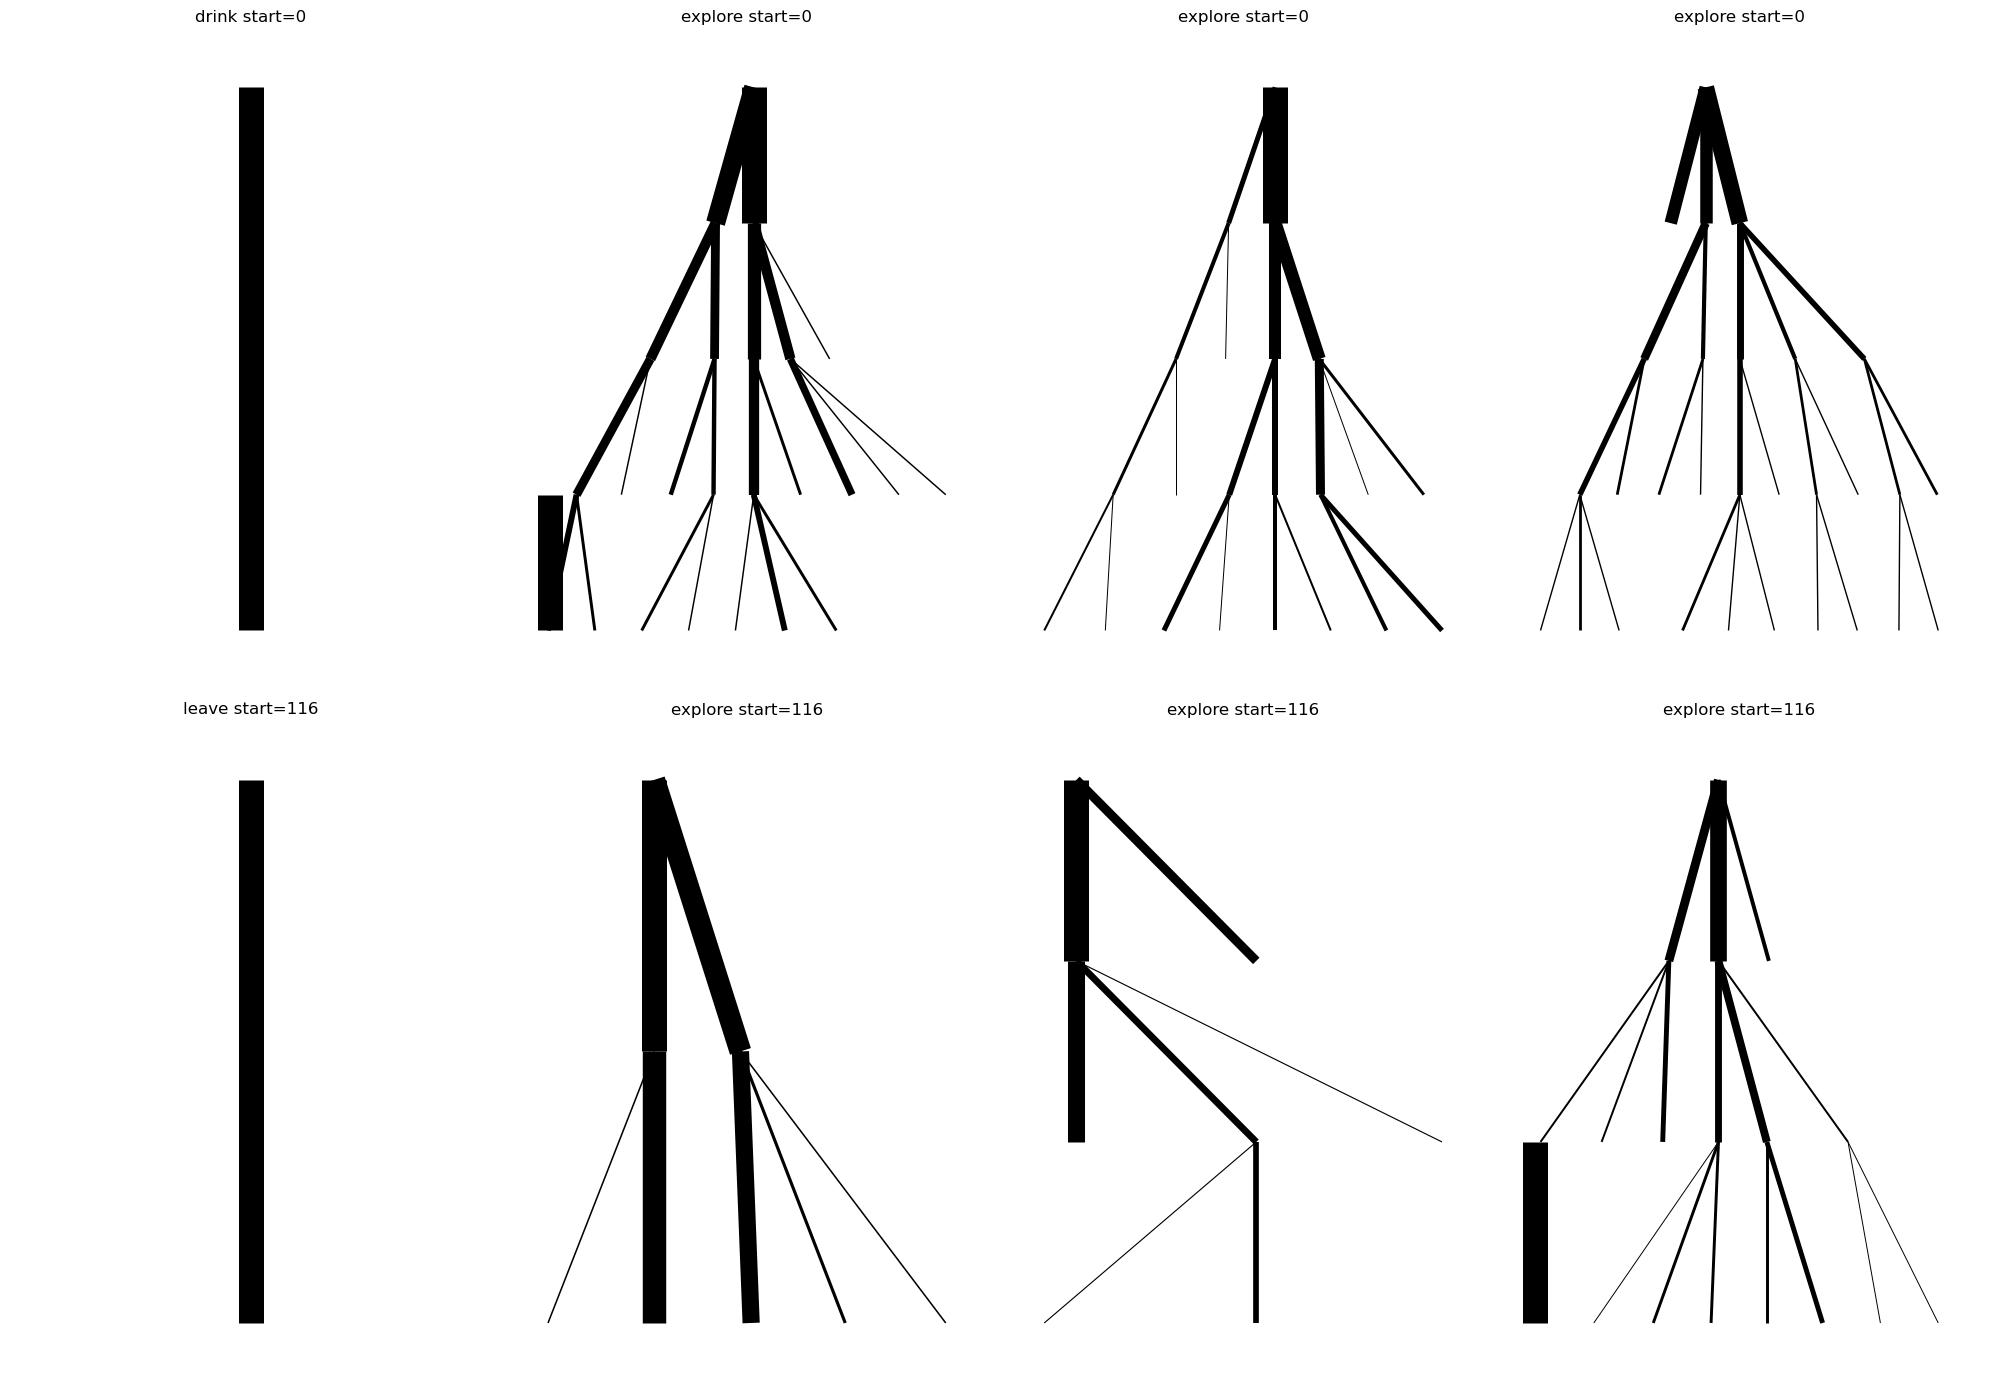

In [175]:
from scipy import stats
import random

MODES = ["leave", "drink", "explore"]

fig, axes = plt.subplots(2, 4, figsize=(20, 14))

random.seed(2)

trees_dict = {}
for i in range(3):
    for j, root in enumerate(["0", "116"]):
        ax = axes[j, i]
        trajs = [
            [str(t) for t in traj][:5]
            for traj in mode_traj_dict[i]
            if traj[0] == int(root)
        ]

        if len(trajs) > 0:
            trees = []
            rand_trees = []

            for k in range(7):
                kfold_trajs = random.sample(trajs, 30)

                tree = generate_flow_tree_from_trajs(kfold_trajs, END_NODE=".G")
                # print(tree.nodes())
                trees.append(tree)

                rand_trajs = []
                while len(rand_trajs) < 30:
                    rw = MakeRandomWalk(
                        ma,
                        n=100,
                        rs=random.randint(1, 100),
                    )
                    tj = rw.no[0][:, 0]
                    if int(root) in tj:
                        idxs = np.where(tj == int(root))[0]
                        for idx in idxs:
                            if (100 - idx) > 5:
                                this_traj = [str(t) for t in tj[idx : idx + 5]]
                                rand_trajs.append(this_traj)
                tree = generate_flow_tree_from_trajs(rand_trajs, END_NODE=".G")
                rand_trees.append(tree)

            plot_flow_tree(
                trees[4],
                MODES[i] + " start=" + root,
                ax,
                just_edges=True,
                edge_boldness=3,
            )
            plot_flow_tree(
                trees[2],
                MODES[i] + " start=" + root,
                axes[j, i - 1],
                just_edges=True,
                edge_boldness=3,
            )

            group1_features = np.array([extract_tree_features(G, root) for G in trees])
            # print(group1_features.shape)
            # print(group1_features.mean(axis=0))

            if i == 2:
                trees_dict[root] = trees[:]
                trees_dict[root + "rand"] = rand_trees[:]
                plot_flow_tree(
                    rand_trees[4],
                    MODES[i] + " start=" + root,
                    axes[j, 3],
                    just_edges=True,
                    edge_boldness=2,
                )


group1_features = np.array([extract_tree_features(G, "0") for G in trees_dict["0"]])
randg1_features = np.array([extract_tree_features(G, "0") for G in trees_dict["0rand"]])
group2_features = np.array([extract_tree_features(G, "116") for G in trees_dict["116"]])
randg2_features = np.array(
    [extract_tree_features(G, "116") for G in trees_dict["116rand"]]
)


print(group1_features.mean(axis=0))
print("rand", randg1_features.mean(axis=0))
print(group2_features.mean(axis=0))
print("rand", randg2_features.mean(axis=0))

compares = [
    ("Explore: start vs. water", group1_features, group2_features),
    ("Random: start vs. water", randg1_features, randg2_features),
    ("Start: explore v. random", group1_features, randg1_features),
    ("Water: explore vs. random", group2_features, randg2_features),
]

# num_nodes,
# num_leaves,
# depth,
# avg_branching_factor,
# backbone_thickness,
# diameter,
for n, g1, g2 in compares:
    print(n)
    sstr = ""
    for feat in [0, 1, 2, -1, -3, -2]:
        # t_stat, p_val = stats.ttest_ind(group1_features[:, feat], group2_features[:, feat])
        # print("0 vs 116", t_stat, p_val)

        # t_stat, p_val = stats.ttest_ind(group1_features[:, feat], randg1_features[:, feat])
        # print("0 vs rand0", t_stat, p_val)
        print(g1[:, feat].mean(), g2[:, feat].mean())
        t_stat, p_val = run_homemade_permutation_test(
            g1[:, feat], g2[:, feat], n_permutations=10000
        )
        # stats.ttest_ind(g1[:, feat], g2[:, feat], equal_var=False)
        if p_val < 0.002:
            sstr += f"& \\textbf{{{t_stat:.1f}}} & \\textbf{{*}} "
        elif p_val < 0.01:
            sstr += f"& \\textbf{{{t_stat:.1f}}} & \\textbf{{{p_val:.3f}}} "
        else:
            sstr += f"& {t_stat:.1f} & {p_val:.3f} "

    print(sstr)

plt.tight_layout()
print("explore bouts starting at 0 are different than those starting at water")
plt.show()


In [151]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms


def confidence_ellipse(x, y, ax, n_std=3.0, facecolor="none", **kwargs):
    """
    Create a plot of the covariance confidence ellipse of *x* and *y*.

    Parameters
    ----------
    x, y : array-like, shape (n, )
        Input data.

    ax : matplotlib.axes.Axes
        The Axes object to draw the ellipse into.

    n_std : float
        The number of standard deviations to determine the ellipse's radiuses.

    **kwargs
        Forwarded to `~matplotlib.patches.Ellipse`

    Returns
    -------
    matplotlib.patches.Ellipse
    """
    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    # Using a special case to obtain the eigenvalues of this
    # two-dimensional dataset.
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse(
        (0, 0),
        width=ell_radius_x * 2,
        height=ell_radius_y * 2,
        facecolor=facecolor,
        **kwargs,
    )

    # Calculating the standard deviation of x from
    # the squareroot of the variance and multiplying
    # with the given number of standard deviations.
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)

    # calculating the standard deviation of y ...
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)

    transf = (
        transforms.Affine2D()
        .rotate_deg(45)
        .scale(scale_x, scale_y)
        .translate(mean_x, mean_y)
    )

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

[0.87747848 0.05554899]
[[ 0.42243361  0.4078169   0.40579585  0.40350377 -0.39834032  0.41118688]
 [ 0.31659589  0.56252908 -0.50807139  0.29874813  0.31517169 -0.36960506]]


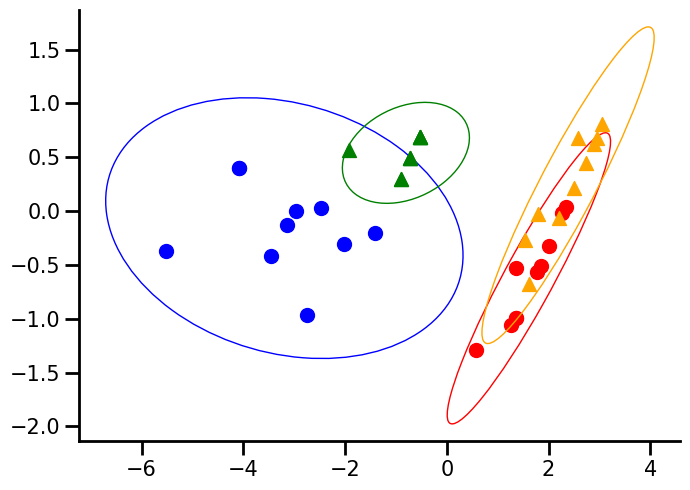

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

group1_features = np.array([extract_tree_features(G, "0") for G in trees_dict["0"]])
randg1_features = np.array([extract_tree_features(G, "0") for G in trees_dict["0rand"]])
group2_features = np.array([extract_tree_features(G, "116") for G in trees_dict["116"]])
randg2_features = np.array(
    [extract_tree_features(G, "116") for G in trees_dict["116rand"]]
)

n = len(group1_features)
colors = ["red", "orange", "blue", "green"]
markers = ["o", "^", "o", "^"]
X = np.concatenate([group1_features, randg1_features, group2_features, randg2_features])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
print(pca.components_)
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
for i in range(4):
    ax.scatter(
        X_pca[n * i : n * (i + 1), 0],
        X_pca[n * i : n * (i + 1), 1],
        c=colors[i],
        marker=markers[i],
        s=100,
    )
    confidence_ellipse(
        X_pca[n * i : n * (i + 1), 0],
        X_pca[n * i : n * (i + 1), 1],
        ax,
        edgecolor=colors[i],
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)
ax.tick_params(axis="both", which="major", labelsize=15, width=2, length=10)


plt.tight_layout()
plt.show()

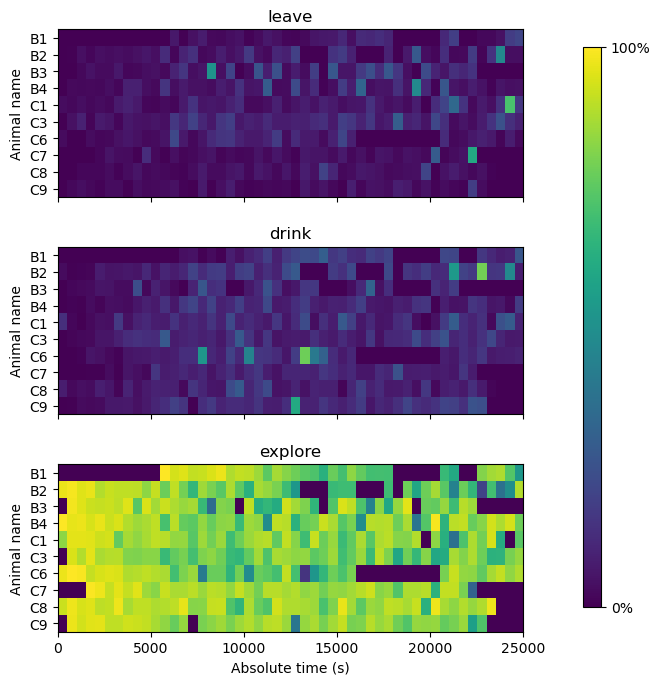

In [17]:
# Plot fraction of each mode for each animal
# leave=0; drink=1; explore=2 # the 3 modes
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 8))
mode = ["leave", "drink", "explore"]
for i, m in enumerate(mode):
    ax = axes[i]
    ax.imshow(tf[:, :, i], vmin=0, vmax=1)
    ax.set_aspect(1.8)
    ax.set_xticks(np.linspace(-0.5, nb - 0.5, 6))
    ax.set_xticklabels([])
    ax.set_yticks(np.arange(ti.shape[0]))
    ax.set_yticklabels(Names)
    ax.set_ylabel("Animal name")
    ax.set_title(m)
ax.set_xticklabels(["0", "5000", "10000", "15000", "20000", "25000"])
ax.set_xlabel("Absolute time (s)")
cax = fig.add_axes([1.0, 0.15, 0.03, 0.7])
sm = plt.cm.ScalarMappable()
cbar = plt.colorbar(sm, cax=cax)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["0%", "100%"])
cbar.ax.tick_params(labelsize=10)
# plt.savefig('figs/TimeInMazeImg.pdf',bbox_inches = "tight")
plt.show()

In [18]:
# average the mode fractions across animals, but only when the animal was in the maze
tfm = np.array(
    [np.mean(tf[ts[:, i] > 0, i, :], axis=0) for i in range(ts.shape[1])]
)  # mean
tfs = np.array(
    [np.std(tf[ts[:, i] > 0, i, :], axis=0) for i in range(ts.shape[1])]
)  # std

In [30]:
# Mean across all animals
E = np.concatenate([32 / Rpars[:, 0], 32 / Upars[:, 0]])
print("              Mean    Std dev Std err")
print(
    "All animals:  {:5.3f}   {:5.3f}   {:5.3f}".format(
        np.mean(E), np.std(E), np.std(E) / np.sqrt(len(E))
    )
)


              Mean    Std dev Std err
All animals:  0.387   0.044   0.010
